# V62: Core Comparison - AI Graph vs Static Markowitz

## Tujuan Eksperimen

Notebook ini membandingkan **3 strategi inti**:

### Strategi yang Dibandingkan:

1. **Static Markowitz (Baseline)**
   - Buy & Hold tanpa AI timing
   - Semua aset, no filtering
   - Rebalancing periodik (20 hari)
   - Always invested (no cash)

2. **AI + Graph Diversify**
   - AI-Gated dengan XGBoost
   - Graph filtering (korelasi ≤ 0.4)
   - SMA 50 trend override
   - Dynamic cash allocation

3. **AI + Graph Cluster**
   - AI-Gated dengan XGBoost
   - Graph filtering (korelasi ≥ 0.4)
   - SMA 50 trend override
   - Dynamic cash allocation

### Fokus Eksperimen:
Mengukur **nilai AI + Graph filtering** dibanding baseline Static Markowitz

### Hipotesis:
- **H1:** AI + Graph strategies outperform Static Markowitz
- **H2:** Diversify lebih stabil dari Cluster
- **H3:** Cluster lebih tinggi return di bullish market

### Parameter:
- AI: XGBoost (threshold optimized)
- Trend Override: SMA 50
- Transaction Fee: 0.25%
- Rebalancing: 20 hari
- Correlation Threshold: 0.4
- Random Seed: 42

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import xgboost as xgb
from sklearn.metrics import fbeta_score
import random
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Libraries loaded!")

Libraries loaded!


In [2]:
# Load Data
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)
market_index = (1 + market_return).cumprod() * 100

print(f"Data: {len(data)} rows, {len(data.columns)} assets")
print(f"Period: {data.index[0]} to {data.index[-1]}")

Data: 712 rows, 30 assets
Period: 2023-01-02 00:00:00 to 2025-12-30 00:00:00


In [3]:
# AI Training
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()

sma5 = market_return.rolling(window=5).mean()
sma20 = market_return.rolling(window=20).mean()
target = (sma5 > sma20).astype(int).shift(-5).reindex(features.index).fillna(0)

X_train = features.loc[features.index.year <= 2024].dropna()
y_train = target.loc[X_train.index]
X_test = features.loc[features.index.year == 2025]

xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, 
                              random_state=SEED, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

train_probs = xgb_model.predict_proba(X_train)[:, 1]
opt_t = np.linspace(0.3, 0.7, 41)[np.argmax([fbeta_score(y_train, (train_probs >= t).astype(int), beta=0.5) 
                                              for t in np.linspace(0.3, 0.7, 41)])]
test_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=X_test.index)

print(f"Optimized Threshold: {opt_t:.2f}")

Optimized Threshold: 0.54


In [4]:
# Markowitz Optimization

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    num_assets = len(mu)

    def objective(w):
        ret = np.sum(w * mu)
        risk = np.sqrt(np.dot(w.T, np.dot(sigma, w)))
        if risk < 0.0001: return 0
        return -(ret / risk)

    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(num_assets))
    init_guess = [1./num_assets] * num_assets

    res = minimize(objective, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

print("Markowitz optimization defined!")

Markowitz optimization defined!


In [5]:
# Asset Selection Methods

def get_all_assets(returns_window, corr_threshold=None):
    """Static Markowitz: All assets"""
    return list(returns_window.columns)

def get_assets_graph_diversify(returns_window, corr_threshold=0.4):
    """AI + Graph Diversify: Low correlation (≤ 0.4)"""
    corr_mat = returns_window.corr()
    G = nx.Graph()
    
    momentum = returns_window.mean()
    assets = list(momentum.sort_values(ascending=False).index)
    
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.loc[assets[i], assets[j]]) > corr_threshold:
                G.add_edge(assets[i], assets[j])
    
    return list(nx.approximation.maximum_independent_set(G))

def get_assets_graph_cluster(returns_window, corr_threshold=0.4):
    """AI + Graph Cluster: High correlation (≥ 0.4)"""
    corr_mat = returns_window.corr()
    G = nx.Graph()
    
    momentum = returns_window.mean()
    assets = list(momentum.sort_values(ascending=False).index)
    
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.loc[assets[i], assets[j]]) < corr_threshold:
                G.add_edge(assets[i], assets[j])
    
    return list(nx.approximation.maximum_independent_set(G))

print("Asset selection methods defined!")

Asset selection methods defined!


In [6]:
# Simulation Function (AI-Gated)

def run_simulation_ai_gated(test_dates, returns, ai_probs, threshold, market_idx, 
                            selection_func, override_ma=None, fee=0.0025, 
                            g_lookback=60, rebal_period=20, turnover_buffer=0.05):
    
    val = 100.0
    history = [val]
    dates = [test_dates[0]]
    
    current_weights = {} 
    risk_status = False 
    days_since_rebal = 999
    
    market_ma = None
    if override_ma:
        market_ma = market_idx.rolling(window=override_ma).mean()
    
    for i, date in enumerate(test_dates[:-1]):
        prev_risk_status = risk_status
        prob = ai_probs.loc[date]
        
        # AI Signal
        ai_signal = False
        buffer = 0.05
        if not risk_status and prob > (threshold + buffer): 
            ai_signal = True
        elif risk_status and prob < (threshold - buffer): 
            ai_signal = False
        else: 
            ai_signal = risk_status
        
        # Trend Override
        final_signal = ai_signal
        if override_ma and market_ma is not None:
            try:
                current_price = market_idx.loc[date]
                ma_price = market_ma.loc[date]
                if not pd.isna(ma_price) and not pd.isna(current_price):
                    is_uptrend = (current_price > ma_price)
                    if ai_signal == False and is_uptrend:
                        final_signal = True
            except KeyError:
                pass
        
        risk_status = final_signal
        regime_changed = (risk_status != prev_risk_status)
        
        target_weights = current_weights.copy()
        
        if not risk_status:
            if regime_changed or 'CASH' not in current_weights or current_weights.get('CASH', 0) < 0.99:
                target_weights = {'CASH': 1.0}
                days_since_rebal = 0
        else:
            if regime_changed or days_since_rebal >= rebal_period:
                loc_idx = returns.index.get_loc(date)
                window_rets = returns.iloc[loc_idx-g_lookback:loc_idx]
                
                selected = selection_func(window_rets)
                optimized_weights = optimize_markowitz(window_rets[selected])
                
                all_keys = set(list(optimized_weights.keys()) + list(current_weights.keys()))
                turnover_est = sum(abs(optimized_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys)
                
                if regime_changed or turnover_est > turnover_buffer:
                    target_weights = optimized_weights
                    days_since_rebal = 0
            
            days_since_rebal += 1

        # Execution
        all_keys_exec = set(list(target_weights.keys()) + list(current_weights.keys()))
        turnover_actual = sum(abs(target_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys_exec)
        
        if turnover_actual > 0.001:
            cost = val * turnover_actual * fee
            val -= cost
        
        next_date = test_dates[i+1]
        day_ret = 0
        new_weights_drifted = {}
        
        if 'CASH' in target_weights and target_weights['CASH'] > 0.99:
            day_ret = 0
            new_weights_drifted = {'CASH': 1.0}
        else:
            for asset, w in target_weights.items():
                if asset in returns.columns:
                    r = returns.loc[next_date, asset]
                    r_asset = r if not pd.isna(r) else 0
                    day_ret += w * r_asset
                    new_weights_drifted[asset] = w * (1 + r_asset)
                else:
                    new_weights_drifted[asset] = w
            
            total_w = sum(new_weights_drifted.values()) if new_weights_drifted else 0
            if total_w > 0:
                new_weights_drifted = {k: v/total_w for k, v in new_weights_drifted.items()}
        
        val *= (1 + day_ret)
        history.append(val)
        dates.append(next_date)
        current_weights = new_weights_drifted
    
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

print("AI-Gated simulation ready!")

AI-Gated simulation ready!


In [7]:
# Simulation Function (Static)

def run_simulation_static(test_dates, returns, selection_func, fee=0.0025, 
                         g_lookback=60, rebal_period=20, turnover_buffer=0.05):
    
    val = 100.0
    history = [val]
    dates = [test_dates[0]]
    
    current_weights = {}
    days_since_rebal = 999
    
    loc_idx = returns.index.get_loc(test_dates[0])
    window_rets = returns.iloc[loc_idx-g_lookback:loc_idx]
    selected = selection_func(window_rets)
    current_weights = optimize_markowitz(window_rets[selected])
    
    for i, date in enumerate(test_dates[:-1]):
        target_weights = current_weights.copy()
        
        if days_since_rebal >= rebal_period:
            loc_idx = returns.index.get_loc(date)
            window_rets = returns.iloc[loc_idx-g_lookback:loc_idx]
            
            selected = selection_func(window_rets)
            optimized_weights = optimize_markowitz(window_rets[selected])
            
            all_keys = set(list(optimized_weights.keys()) + list(current_weights.keys()))
            turnover_est = sum(abs(optimized_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys)
            
            if turnover_est > turnover_buffer:
                target_weights = optimized_weights
                days_since_rebal = 0
        
        days_since_rebal += 1
        
        all_keys_exec = set(list(target_weights.keys()) + list(current_weights.keys()))
        turnover_actual = sum(abs(target_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys_exec)
        
        if turnover_actual > 0.001:
            cost = val * turnover_actual * fee
            val -= cost
        
        next_date = test_dates[i+1]
        day_ret = 0
        new_weights_drifted = {}
        
        for asset, w in target_weights.items():
            if asset in returns.columns:
                r = returns.loc[next_date, asset]
                r_asset = r if not pd.isna(r) else 0
                day_ret += w * r_asset
                new_weights_drifted[asset] = w * (1 + r_asset)
            else:
                new_weights_drifted[asset] = w
        
        total_w = sum(new_weights_drifted.values()) if new_weights_drifted else 0
        if total_w > 0:
            new_weights_drifted = {k: v/total_w for k, v in new_weights_drifted.items()}
        
        val *= (1 + day_ret)
        history.append(val)
        dates.append(next_date)
        current_weights = new_weights_drifted
    
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

print("Static simulation ready!")

Static simulation ready!


In [8]:
# Run All Strategies

print("Running simulations...\n")

# 1. Static Markowitz (Baseline)
print("1. Static Markowitz (Buy & Hold)...")
static_markowitz = run_simulation_static(X_test.index, returns, get_all_assets)

# 2. AI + Graph Diversify
print("2. AI + Graph Diversify...")
ai_diversify = run_simulation_ai_gated(X_test.index, returns, test_probs, opt_t, market_index, 
                                       get_assets_graph_diversify, override_ma=50)

# 3. AI + Graph Cluster
print("3. AI + Graph Cluster...")
ai_cluster = run_simulation_ai_gated(X_test.index, returns, test_probs, opt_t, market_index, 
                                     get_assets_graph_cluster, override_ma=50)

print("\n=== RESULTS ===")
print(f"Static Markowitz:        {static_markowitz.iloc[-1].values[0]:.2f}")
print(f"AI + Graph Diversify:    {ai_diversify.iloc[-1].values[0]:.2f}")
print(f"AI + Graph Cluster:      {ai_cluster.iloc[-1].values[0]:.2f}")

print("\n=== AI + GRAPH VALUE ===")
diversify_vs_static = ((ai_diversify.iloc[-1].values[0] / static_markowitz.iloc[-1].values[0]) - 1) * 100
cluster_vs_static = ((ai_cluster.iloc[-1].values[0] / static_markowitz.iloc[-1].values[0]) - 1) * 100

print(f"Diversify vs Static:     {diversify_vs_static:+.2f}%")
print(f"Cluster vs Static:       {cluster_vs_static:+.2f}%")

Running simulations...

1. Static Markowitz (Buy & Hold)...
2. AI + Graph Diversify...
3. AI + Graph Cluster...

=== RESULTS ===
Static Markowitz:        170.50
AI + Graph Diversify:    210.90
AI + Graph Cluster:      100.17

=== AI + GRAPH VALUE ===
Diversify vs Static:     +23.69%
Cluster vs Static:       -41.25%


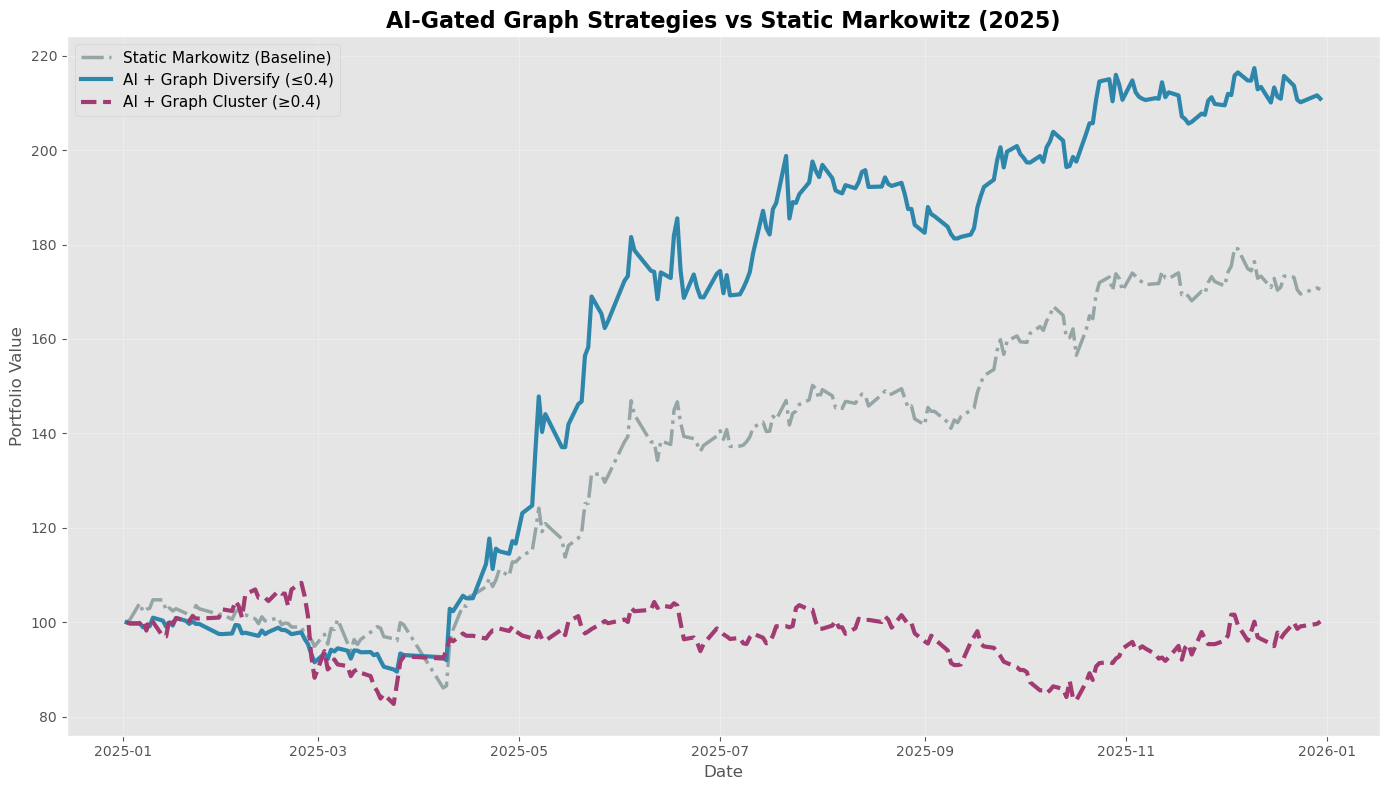


Visualization complete!


In [9]:
# Visualization

plt.figure(figsize=(14, 8))

plt.plot(static_markowitz.index, static_markowitz['Portfolio_Value'], 
         label='Static Markowitz (Baseline)', linewidth=2.5, color='#95A5A6', linestyle='-.')
plt.plot(ai_diversify.index, ai_diversify['Portfolio_Value'], 
         label='AI + Graph Diversify (≤0.4)', linewidth=3, color='#2E86AB')
plt.plot(ai_cluster.index, ai_cluster['Portfolio_Value'], 
         label='AI + Graph Cluster (≥0.4)', linewidth=3, color='#A23B72', linestyle='--')

plt.title('AI-Gated Graph Strategies vs Static Markowitz (2025)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Portfolio Value', fontsize=12)
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nVisualization complete!")

In [10]:
# Risk Metrics

def calculate_metrics(portfolio_values):
    returns = portfolio_values.pct_change().dropna()
    
    total_return = (portfolio_values.iloc[-1] / portfolio_values.iloc[0] - 1) * 100
    volatility = returns.std() * np.sqrt(252) * 100
    sharpe = (returns.mean() / returns.std()) * np.sqrt(252) if returns.std() > 0 else 0
    max_dd = ((portfolio_values / portfolio_values.cummax()) - 1).min() * 100
    
    return {
        'Total Return (%)': total_return,
        'Volatility (%)': volatility,
        'Sharpe Ratio': sharpe,
        'Max Drawdown (%)': max_dd
    }

results_df = pd.DataFrame({
    'Static Markowitz': calculate_metrics(static_markowitz['Portfolio_Value']),
    'AI + Diversify': calculate_metrics(ai_diversify['Portfolio_Value']),
    'AI + Cluster': calculate_metrics(ai_cluster['Portfolio_Value'])
}).T

print("\n=== RISK METRICS ===")
print(results_df.round(2))

# Export to Excel
output_file = 'v62_core_comparison_results.xlsx'
results_df.to_excel(output_file)
print(f"\nResults exported to: {output_file}")


=== RISK METRICS ===
                  Total Return (%)  Volatility (%)  Sharpe Ratio  \
Static Markowitz             70.50           32.66          1.92   
AI + Diversify              110.90           35.64          2.42   
AI + Cluster                  0.17           30.46          0.16   

                  Max Drawdown (%)  
Static Markowitz            -17.82  
AI + Diversify              -11.33  
AI + Cluster                -23.68  

Results exported to: v62_core_comparison_results.xlsx


## Kesimpulan

### Interpretasi Hasil:

1. **Static Markowitz (Baseline)**:
   - Buy & Hold, always invested
   - No AI timing, no graph filtering
   - Baseline untuk mengukur AI + Graph value

2. **AI + Graph Diversify**:
   - AI regime prediction + diversifikasi
   - Dynamic cash allocation
   - Expected: Higher Sharpe, lower drawdown

3. **AI + Graph Cluster**:
   - AI regime prediction + clustering
   - Sector momentum capture
   - Expected: Higher return (bullish), higher risk

### Nilai AI + Graph:

**Jika AI strategies >> Static:**
- AI timing sangat valuable
- Graph filtering enhance performance
- Worth the complexity

**Jika Diversify > Cluster:**
- Risk management lebih penting
- Diversifikasi superior untuk risk-adjusted return

**Jika Cluster > Diversify:**
- Momentum capture powerful (bullish market)
- Clustering effective untuk trend following

### Rekomendasi:
- **Best Sharpe Ratio** → Optimal risk-adjusted strategy
- **Lowest Drawdown** → Best capital preservation
- **Best Return** → Aggressive growth strategy
- Compare Sharpe ratio untuk fair comparison